# PCA analysis of City Lifestyle dataset 

## Load the packages

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import os

## Load and explore the data

In [8]:
os.getcwd()

'c:\\Users\\hanna\\OneDrive\\Bureau\\uni\\tp_city_lifestyle\\notebooks'

In [9]:
data = pd.read_csv('../data/city_lifestyle_dataset.csv')

In [11]:
print(data.head())
print(data.describe())
print(data.info())

       city_name country  population_density  avg_income  \
0      Old Vista  Europe                2775        3850   
1      Beachport  Europe                3861        3700   
2  Valleyborough  Europe                2562        4310   
3           City  Europe                3192        3970   
4          Falls  Europe                3496        4320   

   internet_penetration  avg_rent  air_quality_index  public_transport_score  \
0                  86.4      1310                 43                    52.0   
1                  78.1      1330                 42                    62.8   
2                  80.1      1330                 39                    73.2   
3                  81.2      1480                 60                    49.2   
4                 100.0      1510                 64                    93.7   

   happiness_score  green_space_ratio  
0              8.5               23.8  
1              8.1               33.1  
2              8.5               40.2 

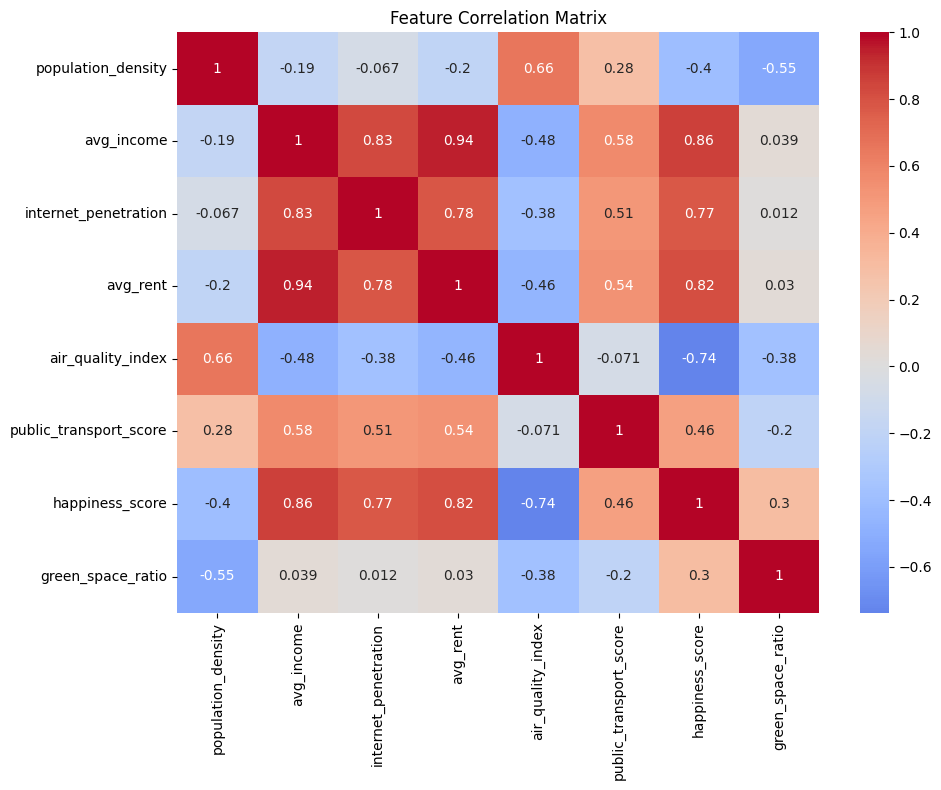

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.select_dtypes(include='number').corr(), 
            annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## Prepare data for the PCA

In [15]:
# prepare data for PCA
X = data.drop(['city_name', 'country'], axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## K-means

In [19]:
kmeans = KMeans(n_clusters=5, random_state=42)
data['cluster'] = kmeans.fit_predict(X_scaled)

## PCA

In [20]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

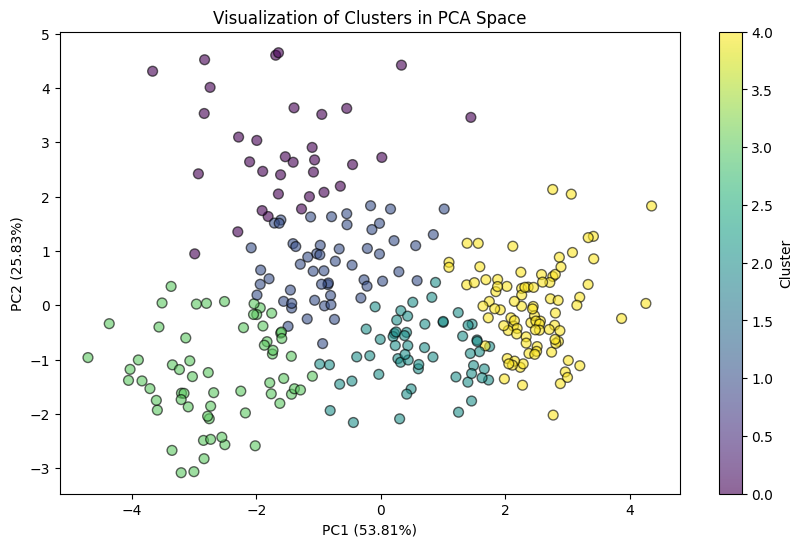

         population_density   avg_income  internet_penetration     avg_rent  \
cluster                                                                       
0              10196.424242  2606.666667             73.790909   913.333333   
1               5984.709091  2371.090909             71.934545   828.909091   
2               2595.543860  2920.350877             76.731579  1042.631579   
3               2722.285714  1220.793651             50.758730   420.793651   
4               2156.108696  4221.304348             90.528261  1512.608696   

         air_quality_index  public_transport_score  happiness_score  \
cluster                                                               
0               114.030303               65.015152         5.045455   
1                82.781818               59.381818         6.065455   
2                58.771930               51.289474         7.578947   
3                79.952381               38.446032         4.600000   
4                50.

In [22]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=data['cluster'], cmap='viridis', 
                     alpha=0.6, edgecolors='k', s=50)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title('Visualization of Clusters in PCA Space')
plt.colorbar(scatter, label='Cluster')
plt.show()

print(data.groupby('cluster')[X.columns].mean())

On note que les 2 premiers composantes expliquent 79.6% de la variance totale.    
Le graphique montre 5 clusters distincts. Le cluster 4 représente des villes qui ont un lien fort avec les revenus, loyers, taux de foyers ayant un accès à l’internet et niveaux de bonheur les plus élevés. Le cluster 2 correspond à des villes équilibrées et agréables à vivre avec de bonnes conditions environnementales. Le cluster 3 comprend des villes à revenu plus faible. Le cluster 1 regroupe des villes de moyenne taille avec des indicateurs modérés, tandis que le cluster 0 rassemble des villes très densément peuplées avec une qualité de l’air plus mauvaise.    

## Save the embeddings

In [23]:
data_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

In [24]:
data_pca.to_csv("../outputs/pca_emb_2d.csv", index=False)